# 02d — Ball map send focus to origin

Uses `ball_to_origin_array` from `ball_projection.py` on stereographic **R³** ball coordinates (diagnostic chart).


### Poincaré-ball isometry moving one focus to the origin

**Method:** After stereographic projection to ℝ³, treat coordinates inside the **unit ball** as a Poincaré-ball chart (curvature −1). `ball_to_origin_array` applies the Möbius addition isometry that sends the first vertex’s image to **0**, then subsamples for plotting.

**How to read the output:** The red point at the origin is the mapped focus; the rest of the cloud shows the embedding **relative** to that protein in ball geometry. This is a diagnostic for ball charts, not a substitute for native hyperboloid distances.


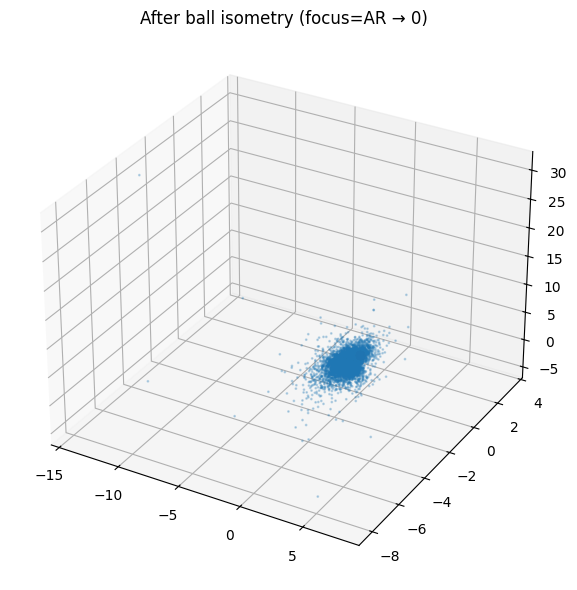

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

import dmercator3d_io as dm
from ball_projection import stereographic_s3_to_r3, ball_to_origin_array

merged = dm.load_merged_parquet(Path("cache/merged.parquet"))
U = dm.normalize_direction_nd(merged)
x1, x2, x3, x4 = U[:, 0], U[:, 1], U[:, 2], U[:, 3]
X, Y, Z = stereographic_s3_to_r3(x1, x2, x3, x4, pole="north")
focus = merged["Vertex"].iloc[0]
mf = (merged["Vertex"] == focus).to_numpy()
ax0, ay0, az0 = float(X[mf][0]), float(Y[mf][0]), float(Z[mf][0])
pts = np.column_stack([X, Y, Z])
out = ball_to_origin_array(ax0, ay0, az0, pts)
rng = np.random.default_rng(3)
sub = rng.choice(len(out), size=min(8000, len(out)), replace=False)
fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(out[sub, 0], out[sub, 1], out[sub, 2], s=1, alpha=0.25)
ax.scatter([0], [0], [0], c="r", s=40)
ax.set_title(f"After ball isometry (focus={focus} → 0)")
plt.tight_layout()
plt.show()
